# ClimateWell-FuseNet: Hierarchical Gated Deep Fusion Architecture

This notebook implements a **novel deep-learning architecture candidate** for your climate-policy well-being screening and theme annotation task.

The design keeps **BGE + TF-IDF** as the baseline idea, then adds **SPECTER** and converts the previous classical feature-concatenation pipeline into a trainable neural architecture:

1. **BGE encoder**: general semantic representation.
2. **SPECTER encoder**: scientific-document representation.
3. **TF-IDF/SVD lexical branch**: climate-policy keyword signal.
4. **Trainable gated fusion layer**: learns how much to trust each branch.
5. **Hierarchical multi-task heads**: Accept/Reject + accepted-only theme prediction.
6. **Theme prototype module**: improves low-resource theme learning.
7. **Uncertainty-aware review priority**: ranks predictions for human checking.

> Important wording: after this notebook runs, you can describe the method as a **proposed novel hierarchical gated fusion architecture**. You should only claim it is empirically superior if its metrics improve over your baselines.

## Expected contribution statement

You can use wording like this in your report:

> This study proposes **ClimateWell-FuseNet**, a hierarchical gated scientific-semantic fusion architecture for climate-policy well-being evidence classification. The model integrates general semantic embeddings, scientific-document embeddings, and lexical policy features through trainable projection and gating layers. It jointly optimises binary relevance screening and accepted-only theme annotation, while a prototype-based theme module and uncertainty-aware review score support low-resource, imbalanced evidence annotation.

In [ ]:

# ============================================================
# 0. Optional installs
# ============================================================
# On Kaggle/Colab, uncomment this cell if packages are missing.
# !pip install -q transformers sentence-transformers scikit-learn openpyxl pandas numpy torch matplotlib tqdm

## P100 GPU-only setup

Run the next cell first in Kaggle with **Accelerator = GPU P100** and **Internet = On**. If your current PyTorch build cannot execute CUDA kernels on P100, the cell installs a CUDA 11.8 PyTorch build and restarts the kernel automatically. After the restart, run the notebook from the top again.

This notebook intentionally does **not** fall back to CPU. If CUDA is unavailable or unusable, it stops with an error.

In [1]:

# ============================================================
# P100 GPU-only PyTorch repair cell
# ============================================================
# Purpose: Kaggle sometimes ships a PyTorch/CUDA build that sees the P100
# but cannot execute kernels on compute capability 6.0. This cell verifies
# CUDA execution. If it fails, it installs a CUDA 11.8 PyTorch build and
# restarts the kernel. Re-run the notebook from the top after restart.

import os, sys, subprocess, textwrap


def _torch_cuda_smoke_test(verbose=True):
    try:
        import torch
        if verbose:
            print("Torch version:", torch.__version__)
            print("Torch CUDA build:", torch.version.cuda)
            print("CUDA available:", torch.cuda.is_available())
        if not torch.cuda.is_available():
            return False, "torch.cuda.is_available() is False"
        name = torch.cuda.get_device_name(0)
        cc = torch.cuda.get_device_capability(0)
        if verbose:
            print("GPU:", name, "| compute capability:", cc)
        # Actual kernel execution test. This is what failed in your traceback.
        x = torch.ones((128, 128), device="cuda", dtype=torch.float32)
        y = x @ x
        torch.cuda.synchronize()
        _ = float(y[0, 0].detach().cpu())
        return True, f"CUDA kernel test passed on {name}"
    except Exception as e:
        return False, repr(e)

ok, msg = _torch_cuda_smoke_test(verbose=True)
print("CUDA smoke test:", msg)

if not ok:
    print("\nInstalling a P100-compatible CUDA PyTorch build. This needs Kaggle Internet = On.")
    print("After installation, the kernel will restart automatically. Then run all cells again.\n")
    commands = [
        [sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio", "triton"],
        [sys.executable, "-m", "pip", "install", "--no-cache-dir", "--force-reinstall",
         "torch==2.5.1", "torchvision==0.20.1", "torchaudio==2.5.1",
         "--index-url", "https://download.pytorch.org/whl/cu118"],
        [sys.executable, "-m", "pip", "install", "-q", "--upgrade",
         "transformers==4.46.3", "sentence-transformers==3.3.1", "accelerate==1.1.1"],
    ]
    for cmd in commands:
        print("Running:", " ".join(cmd))
        subprocess.check_call(cmd)
    print("\nInstalled compatible packages. Restarting kernel now...")
    os.kill(os.getpid(), 9)
else:
    print("GPU is usable. Continuing with P100/CUDA execution only.")


Torch version: 2.5.1+cu118
Torch CUDA build: 11.8
CUDA available: True
GPU: Tesla P100-PCIE-16GB | compute capability: (6, 0)
CUDA smoke test: CUDA kernel test passed on Tesla P100-PCIE-16GB
GPU is usable. Continuing with P100/CUDA execution only.


In [2]:

# ============================================================
# 1. Imports and global configuration
# ============================================================
import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    average_precision_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# GPU-only policy: do not fall back to CPU.
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU-only notebook: CUDA is not available. In Kaggle, set Accelerator = GPU P100, "
        "turn Internet On, run the P100 repair cell above, restart, and rerun."
    )
DEVICE = "cuda"
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)

# P100 does not support bf16; keep the notebook in fp32 CUDA mode.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# Real CUDA kernel test; fail fast if the current PyTorch build cannot run on P100.
try:
    _x = torch.ones((128, 128), device="cuda", dtype=torch.float32)
    _y = _x @ _x
    torch.cuda.synchronize()
    print("CUDA kernel smoke test passed.")
except Exception as e:
    raise RuntimeError(
        "CUDA is visible but unusable on this P100 runtime. Run the P100 repair cell above, "
        "restart the kernel, then rerun all cells. Original error: " + repr(e)
    )

# -----------------------------
# Paths
# -----------------------------
TRAIN_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/Human labelled_DTU.xlsx"),
    Path("/mnt/data/Human labelled_DTU.xlsx"),
    Path("Human labelled_DTU.xlsx"),
]
MASTER_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Master.xlsx"),
    Path("/kaggle/input/Master.xlsx"),
    Path("/mnt/data/Master.xlsx"),
    Path("Master.xlsx"),
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

TRAIN_FILE = first_existing(TRAIN_FILE_CANDIDATES)
MASTER_FILE = first_existing(MASTER_FILE_CANDIDATES)

OUTPUT_DIR = Path("/kaggle/working/climatewell_fusenet_outputs") if Path("/kaggle/working").exists() else Path("./climatewell_fusenet_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache_embeddings"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("TRAIN_FILE:", TRAIN_FILE)
print("MASTER_FILE:", MASTER_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)

# -----------------------------
# Experiment settings
# -----------------------------
N_SPLITS = 5
MAX_EPOCHS = 50
PATIENCE = 8
BATCH_SIZE = 32
LR = 2e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 256
DROPOUT = 0.30
THEME_LOSS_WEIGHT = 1.25
PROTO_LOGIT_WEIGHT = 0.35
PROTO_TEMPERATURE = 0.08

# TF-IDF/SVD branch
WORD_MAX_FEATURES = 20000
CHAR_MAX_FEATURES = 20000
SVD_DIM = 256

# Sentence embedding models
BGE_MODEL_NAME = "BAAI/bge-small-en-v1.5"
SPECTER_MODEL_NAME = "allenai/specter"
EMBED_BATCH_SIZE = 16  # safer for P100 memory during BGE/SPECTER embedding

# Run all neural ablations. To save time, keep only the final one.
EXPERIMENTS = {
    "TFIDF_NN": {"use_bge": False, "use_specter": False, "use_tfidf": True},
    "BGE_NN": {"use_bge": True, "use_specter": False, "use_tfidf": False},
    "SPECTER_NN": {"use_bge": False, "use_specter": True, "use_tfidf": False},
    "BGE_TFIDF_NN_BASELINE": {"use_bge": True, "use_specter": False, "use_tfidf": True},
    "SPECTER_TFIDF_NN": {"use_bge": False, "use_specter": True, "use_tfidf": True},
    "CLIMATEWELL_FUSENET_BGE_SPECTER_TFIDF": {"use_bge": True, "use_specter": True, "use_tfidf": True},
}

FINAL_EXPERIMENT_NAME = "CLIMATEWELL_FUSENET_BGE_SPECTER_TFIDF"

Device: cuda
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)
Torch version: 2.5.1+cu118
Torch CUDA build: 11.8
CUDA kernel smoke test passed.
TRAIN_FILE: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx
MASTER_FILE: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx
OUTPUT_DIR: /kaggle/working/climatewell_fusenet_outputs


In [3]:

# ============================================================
# 2. Data loading utilities
# ============================================================
def clean_text(x) -> str:
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def find_column(columns, keywords):
    cols = list(columns)
    low = {str(c).lower().strip(): c for c in cols}
    for kw in keywords:
        for lc, c in low.items():
            if kw in lc:
                return c
    return None


def decision_to_binary(x):
    s = clean_text(x).lower()
    if s in {"accept", "accepted", "include", "included", "relevant", "yes", "1", "true"}:
        return 1
    if s in {"reject", "rejected", "exclude", "excluded", "irrelevant", "no", "0", "false"}:
        return 0
    if "accept" in s or "include" in s or "relevant" in s:
        return 1
    if "reject" in s or "exclude" in s or "irrelevant" in s:
        return 0
    return np.nan


def build_text(title, abstract):
    title = clean_text(title)
    abstract = clean_text(abstract)
    if title and abstract:
        return f"Title: {title}. Abstract: {abstract}"
    return title or abstract


def load_labelled_training_file(path: Path) -> pd.DataFrame:
    if path is None:
        raise FileNotFoundError("Training file not found. Please update TRAIN_FILE_CANDIDATES.")

    header_df = pd.read_excel(path)
    title_col = find_column(header_df.columns, ["title"])
    abstract_col = find_column(header_df.columns, ["abstract", "summary"])
    decision_col = find_column(header_df.columns, ["decision", "accept", "reject", "label", "screening"])
    theme_col = find_column(header_df.columns, ["theme", "category", "code"])

    if abstract_col is not None and decision_col is not None:
        df = pd.DataFrame()
        df["source"] = header_df[find_column(header_df.columns, ["source"])] if find_column(header_df.columns, ["source"]) else ""
        df["paper_id"] = header_df[find_column(header_df.columns, ["id", "paper"])] if find_column(header_df.columns, ["id", "paper"]) else np.arange(len(header_df))
        df["authors"] = header_df[find_column(header_df.columns, ["author"])] if find_column(header_df.columns, ["author"]) else ""
        df["title"] = header_df[title_col] if title_col is not None else ""
        df["year"] = header_df[find_column(header_df.columns, ["year"])] if find_column(header_df.columns, ["year"]) else ""
        df["doi"] = header_df[find_column(header_df.columns, ["doi"])] if find_column(header_df.columns, ["doi"]) else ""
        df["url"] = header_df[find_column(header_df.columns, ["url", "link"])] if find_column(header_df.columns, ["url", "link"]) else ""
        df["abstract"] = header_df[abstract_col]
        df["decision"] = header_df[decision_col]
        df["theme"] = header_df[theme_col] if theme_col is not None else np.nan
    else:
        # Fallback to the known 10-column format used in earlier notebooks.
        raw = pd.read_excel(path, header=None)
        if raw.shape[1] < 10:
            raise ValueError(
                "Could not infer columns. Expected headers or 10 columns: "
                "source, id, authors, title, year, doi, url, abstract, decision, theme."
            )
        df = raw.iloc[:, :10].copy()
        df.columns = ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]

    for col in ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]:
        if col not in df.columns:
            df[col] = ""

    df["title"] = df["title"].apply(clean_text)
    df["abstract"] = df["abstract"].apply(clean_text)
    df["decision"] = df["decision"].apply(clean_text)
    df["theme"] = df["theme"].apply(clean_text).replace("", np.nan)
    df["text"] = [build_text(t, a) for t, a in zip(df["title"], df["abstract"])]
    df["accept_label"] = df["decision"].apply(decision_to_binary)
    df = df[df["accept_label"].notna()].copy()
    df["accept_label"] = df["accept_label"].astype(int)
    df = df[df["text"].str.len() > 0].copy().reset_index(drop=True)
    return df


def load_master_file(path: Path) -> pd.DataFrame:
    if path is None:
        raise FileNotFoundError("Master file not found. Please update MASTER_FILE_CANDIDATES.")

    header_df = pd.read_excel(path)
    title_col = find_column(header_df.columns, ["title"])
    abstract_col = find_column(header_df.columns, ["abstract", "summary"])

    if abstract_col is not None:
        df = header_df.copy()
        df["title"] = df[title_col].apply(clean_text) if title_col is not None else ""
        df["abstract"] = df[abstract_col].apply(clean_text)
    else:
        raw = pd.read_excel(path, header=None)
        # Fallback: assume similar master format; abstract usually column 7, title column 3.
        df = raw.copy()
        df.columns = [f"col_{i}" for i in range(df.shape[1])]
        df["title"] = raw.iloc[:, 3].apply(clean_text) if raw.shape[1] > 3 else ""
        df["abstract"] = raw.iloc[:, 7].apply(clean_text) if raw.shape[1] > 7 else raw.iloc[:, -1].apply(clean_text)

    df["text"] = [build_text(t, a) for t, a in zip(df["title"], df["abstract"])]
    df = df[df["text"].str.len() > 0].copy().reset_index(drop=True)
    return df

train_df = load_labelled_training_file(TRAIN_FILE)
master_df = load_master_file(MASTER_FILE)

# Theme mapping from accepted rows only.
accepted_theme_mask = (train_df["accept_label"].eq(1)) & train_df["theme"].notna()
theme_names = sorted(train_df.loc[accepted_theme_mask, "theme"].unique().tolist())
theme_to_id = {t: i for i, t in enumerate(theme_names)}
id_to_theme = {i: t for t, i in theme_to_id.items()}
train_df["theme_id"] = train_df["theme"].map(theme_to_id)
N_THEMES = len(theme_names)

print("Training rows:", len(train_df))
print("Master rows:", len(master_df))
print("Accept count:", int(train_df["accept_label"].sum()))
print("Reject count:", int((1-train_df["accept_label"]).sum()))
print("Accept rate:", train_df["accept_label"].mean())
print("Accepted rows with theme:", int(accepted_theme_mask.sum()))
print("Number of themes:", N_THEMES)
display(train_df.head(3))
display(train_df.loc[accepted_theme_mask, "theme"].value_counts().rename_axis("theme").reset_index(name="count"))

Training rows: 1721
Master rows: 10176
Accept count: 200
Reject count: 1521
Accept rate: 0.11621150493898896
Accepted rows with theme: 199
Number of themes: 13


,source,paper_id,authors,title,year,doi,url,abstract,decision,theme,text,accept_label,theme_id
0,Coder name,Article ID,Paper_Author/s,Paper title,Year of publication,DOI,URL,Abstracts,Accept/Reject,"If Accept, identify theme",Title: Paper title. Abstract: Abstracts,1,6.0
1,Shreya,Scopus_4859,"A.K., Menzies, Allyson K.; E., Bowlesa, E.; M....","""I see my culture starting to disappear"": Anis...",2022,10.1139/facets-2021-0066,NaN,Climate change disproportionately affects Indi...,Accept,"Empowering People & Governance, Policy","Title: ""I see my culture starting to disappear...",1,4.0
2,Shreya,OA_0102,Claudia Quitmann|Rainer Sauerborn|Ina Danquah|...,"‘Climate change mitigation is a hot topic, but...",2022,NaN,https://doi.org/10.1136/medethics-2021-107971,Physical and mental well-being are threatened ...,Reject,NaN,Title: ‘Climate change mitigation is a hot top...,0,NaN


,theme,count
0,Climate change mitigation options & Well-being,84
1,"Empowering People & Governance, Policy",31
2,Implemented mitigation Options and Well-being,21
3,"Well-being, Community & Societal Systems Thinking",11
4,SDGs and Well-being,10
5,"Equity, Social Justice, Just Transition",8
6,Better Well-being Metric,7
7,Integrated Responses and Well-being,6
8,Ecosystem & Non-human Well-being,6
9,Access to Services and Wellbeing,6


In [4]:

# ============================================================
# 3. Embedding generation: BGE and SPECTER
# ============================================================
def save_np(path, arr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, arr.astype(np.float32))


def load_np(path):
    path = Path(path)
    if path.exists():
        return np.load(path)
    return None


def get_bge_embeddings(texts: List[str], cache_name: str) -> np.ndarray:
    cache_path = CACHE_DIR / f"{cache_name}_bge.npy"
    cached = load_np(cache_path)
    if cached is not None and len(cached) == len(texts):
        print(f"Loaded cached BGE embeddings: {cache_path}")
        return cached

    from sentence_transformers import SentenceTransformer
    print("Loading BGE model:", BGE_MODEL_NAME)
    model = SentenceTransformer(BGE_MODEL_NAME, device=DEVICE)
    model = model.float().eval()
    emb = model.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype(np.float32)
    save_np(cache_path, emb)
    return emb


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def get_specter_embeddings(texts: List[str], cache_name: str) -> np.ndarray:
    cache_path = CACHE_DIR / f"{cache_name}_specter.npy"
    cached = load_np(cache_path)
    if cached is not None and len(cached) == len(texts):
        print(f"Loaded cached SPECTER embeddings: {cache_path}")
        return cached

    from transformers import AutoTokenizer, AutoModel
    print("Loading SPECTER model:", SPECTER_MODEL_NAME)
    tokenizer = AutoTokenizer.from_pretrained(SPECTER_MODEL_NAME)
    model = AutoModel.from_pretrained(SPECTER_MODEL_NAME, torch_dtype=torch.float32).to(DEVICE).eval()
    model.eval()

    all_emb = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), EMBED_BATCH_SIZE), desc="SPECTER embeddings"):
            batch = texts[i:i+EMBED_BATCH_SIZE]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt",
            ).to(DEVICE)
            out = model(**enc)
            # SPECTER commonly uses CLS; mean pooling is a stable fallback.
            if hasattr(out, "pooler_output") and out.pooler_output is not None:
                emb = out.pooler_output
            else:
                emb = out.last_hidden_state[:, 0, :]
            emb = F.normalize(emb, p=2, dim=1)
            all_emb.append(emb.detach().cpu().numpy())
    emb = np.vstack(all_emb).astype(np.float32)
    save_np(cache_path, emb)
    return emb

train_texts = train_df["text"].tolist()
master_texts = master_df["text"].tolist()

# Generate/cached embeddings once. These are unsupervised frozen encodings.
BGE_TRAIN = get_bge_embeddings(train_texts, "train")
BGE_MASTER = get_bge_embeddings(master_texts, "master")
SPECTER_TRAIN = get_specter_embeddings(train_texts, "train")
SPECTER_MASTER = get_specter_embeddings(master_texts, "master")

print("BGE train shape:", BGE_TRAIN.shape)
print("SPECTER train shape:", SPECTER_TRAIN.shape)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

2026-05-27 21:44:23.600361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779918263.788525     259 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779918263.839418     259 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779918264.253664     259 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779918264.253696     259 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779918264.253699     259 computation_placer.cc:177] computation placer alr

Loading BGE model: BAAI/bge-small-en-v1.5


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

...

SPECTER embeddings:   0%|          | 0/108 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading SPECTER model: allenai/specter


SPECTER embeddings:   0%|          | 0/636 [00:00<?, ?it/s]

BGE train shape: (1721, 384)
SPECTER train shape: (1721, 768)


In [5]:

# ============================================================
# 4. TF-IDF/SVD branch and preprocessing helpers
# ============================================================
def fit_tfidf_svd(train_texts, valid_texts=None, master_texts=None, svd_dim=SVD_DIM):
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=WORD_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    char_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.95,
        max_features=CHAR_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    Xw = word_vec.fit_transform(train_texts)
    Xc = char_vec.fit_transform(train_texts)
    X_train_sparse = hstack([Xw, Xc]).tocsr()

    max_svd = min(svd_dim, max(2, X_train_sparse.shape[0] - 1), max(2, X_train_sparse.shape[1] - 1))
    svd = TruncatedSVD(n_components=max_svd, random_state=SEED)
    X_train = svd.fit_transform(X_train_sparse).astype(np.float32)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)

    def transform(texts):
        if texts is None:
            return None
        X = hstack([word_vec.transform(texts), char_vec.transform(texts)]).tocsr()
        X = svd.transform(X).astype(np.float32)
        X = scaler.transform(X).astype(np.float32)
        return X

    return {
        "word_vec": word_vec,
        "char_vec": char_vec,
        "svd": svd,
        "scaler": scaler,
        "train": X_train,
        "valid": transform(valid_texts),
        "master": transform(master_texts),
        "transform": transform,
    }


def fit_modality_scaler(train_array, valid_array=None, master_array=None):
    if train_array is None:
        return None, None, None, None
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(train_array).astype(np.float32)
    Xva = scaler.transform(valid_array).astype(np.float32) if valid_array is not None else None
    Xma = scaler.transform(master_array).astype(np.float32) if master_array is not None else None
    return Xtr, Xva, Xma, scaler


def zero_or_array(arr, n_rows, dim):
    if arr is None:
        return np.zeros((n_rows, dim), dtype=np.float32)
    return arr.astype(np.float32)

In [6]:

# ============================================================
# 5. ClimateWell-FuseNet architecture
# ============================================================
class ClimateDataset(Dataset):
    def __init__(self, bge, specter, tfidf, y_bin, y_theme):
        self.bge = torch.tensor(bge, dtype=torch.float32)
        self.specter = torch.tensor(specter, dtype=torch.float32)
        self.tfidf = torch.tensor(tfidf, dtype=torch.float32)
        self.y_bin = torch.tensor(y_bin, dtype=torch.float32)
        self.y_theme = torch.tensor(y_theme, dtype=torch.long)

    def __len__(self):
        return len(self.y_bin)

    def __getitem__(self, idx):
        return {
            "bge": self.bge[idx],
            "specter": self.specter[idx],
            "tfidf": self.tfidf[idx],
            "y_bin": self.y_bin[idx],
            "y_theme": self.y_theme[idx],
        }


class ClimateWellFuseNet(nn.Module):
    # Hierarchical gated fusion network.
    # Branches: BGE semantic, SPECTER scientific-document, and TF-IDF/SVD lexical.
    # Novel architecture components: trainable modality projections, softmax gated
    # fusion, shared representation, binary/theme heads, and theme prototype logits.
    def __init__(
        self,
        bge_dim: int,
        specter_dim: int,
        tfidf_dim: int,
        n_themes: int,
        hidden_dim: int = 256,
        dropout: float = 0.30,
        use_bge: bool = True,
        use_specter: bool = True,
        use_tfidf: bool = True,
        proto_logit_weight: float = 0.35,
        proto_temperature: float = 0.08,
    ):
        super().__init__()
        self.use_bge = use_bge
        self.use_specter = use_specter
        self.use_tfidf = use_tfidf
        self.n_themes = n_themes
        self.proto_logit_weight = proto_logit_weight
        self.proto_temperature = proto_temperature

        def projector(in_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            )

        self.bge_proj = projector(bge_dim)
        self.specter_proj = projector(specter_dim)
        self.tfidf_proj = projector(tfidf_dim)

        self.gate_net = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

        self.shared = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

        self.binary_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

        self.theme_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_themes),
        )

        self.theme_prototypes = nn.Parameter(torch.randn(n_themes, hidden_dim) * 0.02)

    def forward(self, bge, specter, tfidf):
        pb = self.bge_proj(bge)
        ps = self.specter_proj(specter)
        pt = self.tfidf_proj(tfidf)

        raw_gate_logits = self.gate_net(torch.cat([pb, ps, pt], dim=1))

        # Disable absent modalities by assigning a very low gate logit.
        mask = torch.tensor(
            [self.use_bge, self.use_specter, self.use_tfidf],
            dtype=torch.bool,
            device=raw_gate_logits.device,
        )
        gate_logits = raw_gate_logits.masked_fill(~mask.unsqueeze(0), -1e9)
        gates = torch.softmax(gate_logits, dim=1)

        fused = gates[:, 0:1] * pb + gates[:, 1:2] * ps + gates[:, 2:3] * pt
        z = self.shared(fused)

        binary_logits = self.binary_head(z).squeeze(1)

        theme_cls_logits = self.theme_head(z)
        z_norm = F.normalize(z, p=2, dim=1)
        proto_norm = F.normalize(self.theme_prototypes, p=2, dim=1)
        proto_logits = torch.matmul(z_norm, proto_norm.T) / self.proto_temperature
        theme_logits = theme_cls_logits + self.proto_logit_weight * proto_logits

        return {
            "binary_logits": binary_logits,
            "theme_logits": theme_logits,
            "gates": gates,
            "representation": z,
        }

In [7]:

# ============================================================
# 6. Training and evaluation functions
# ============================================================
def binary_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    try:
        ap = average_precision_score(y_true, probs)
    except Exception:
        ap = np.nan
    macro_f1 = f1_score(y_true, pred, average="macro", zero_division=0)
    prec, rec, f1, support = precision_recall_fscore_support(y_true, pred, labels=[0,1], zero_division=0)
    cm = confusion_matrix(y_true, pred, labels=[0,1])
    return {
        "AP": float(ap),
        "binary_macro_f1": float(macro_f1),
        "reject_precision": float(prec[0]),
        "reject_recall": float(rec[0]),
        "reject_f1": float(f1[0]),
        "accept_precision": float(prec[1]),
        "accept_recall": float(rec[1]),
        "accept_f1": float(f1[1]),
        "pred_accept_rate": float(pred.mean()),
        "tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1]),
    }


def tune_threshold(y_true, probs, min_accept_rate=0.07, max_accept_rate=0.18):
    best = None
    for thr in np.linspace(0.05, 0.95, 181):
        pred = (probs >= thr).astype(int)
        rate = pred.mean()
        if not (min_accept_rate <= rate <= max_accept_rate):
            continue
        m = binary_metrics(y_true, probs, thr)
        score = m["binary_macro_f1"] + 0.25 * m["accept_f1"]
        if best is None or score > best["score"]:
            best = {"threshold": float(thr), "score": float(score), **m}
    if best is None:
        # fallback if guardrail is impossible
        for thr in np.linspace(0.05, 0.95, 181):
            m = binary_metrics(y_true, probs, thr)
            score = m["binary_macro_f1"] + 0.25 * m["accept_f1"]
            if best is None or score > best["score"]:
                best = {"threshold": float(thr), "score": float(score), **m}
    return best


def theme_metrics(y_true_theme, probs, theme_names):
    valid = np.array(y_true_theme) >= 0
    if valid.sum() == 0:
        return {}, pd.DataFrame()
    yt = np.array(y_true_theme)[valid].astype(int)
    yp = np.array(probs)[valid].argmax(axis=1)
    macro = f1_score(yt, yp, average="macro", zero_division=0)
    weighted = f1_score(yt, yp, average="weighted", zero_division=0)
    acc = accuracy_score(yt, yp)
    report_dict = classification_report(
        yt,
        yp,
        labels=list(range(len(theme_names))),
        target_names=theme_names,
        output_dict=True,
        zero_division=0,
    )
    rows=[]
    for name in theme_names:
        if name in report_dict:
            r = report_dict[name]
            rows.append({
                "theme": name,
                "precision": r["precision"],
                "recall": r["recall"],
                "f1": r["f1-score"],
                "support": r["support"],
            })
    report_df = pd.DataFrame(rows)
    return {
        "theme_macro_f1": float(macro),
        "theme_weighted_f1": float(weighted),
        "theme_accuracy": float(acc),
        "theme_coverage": int(len(set(yp))),
    }, report_df


def make_loaders(Xb, Xs, Xt, y_bin, y_theme, train_idx, val_idx, batch_size=BATCH_SIZE):
    train_ds = ClimateDataset(Xb[train_idx], Xs[train_idx], Xt[train_idx], y_bin[train_idx], y_theme[train_idx])
    val_ds = ClimateDataset(Xb[val_idx], Xs[val_idx], Xt[val_idx], y_bin[val_idx], y_theme[val_idx])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=0)
    return train_loader, val_loader


def predict_model(model, loader):
    model.eval()
    bin_probs=[]
    theme_probs=[]
    gates=[]
    with torch.no_grad():
        for batch in loader:
            bge = batch["bge"].to(DEVICE)
            specter = batch["specter"].to(DEVICE)
            tfidf = batch["tfidf"].to(DEVICE)
            out = model(bge, specter, tfidf)
            bin_probs.append(torch.sigmoid(out["binary_logits"]).cpu().numpy())
            theme_probs.append(torch.softmax(out["theme_logits"], dim=1).cpu().numpy())
            gates.append(out["gates"].cpu().numpy())
    return np.concatenate(bin_probs), np.vstack(theme_probs), np.vstack(gates)


def train_one_fold(Xb, Xs, Xt, y_bin, y_theme, train_idx, val_idx, exp_cfg, fold_id=0):
    train_loader, val_loader = make_loaders(Xb, Xs, Xt, y_bin, y_theme, train_idx, val_idx)

    pos = max(1, int(y_bin[train_idx].sum()))
    neg = max(1, int(len(train_idx) - y_bin[train_idx].sum()))
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)

    # Theme weights for imbalanced accepted theme labels.
    theme_train = y_theme[train_idx]
    valid_theme = theme_train[theme_train >= 0]
    if len(valid_theme) > 0:
        counts = np.bincount(valid_theme, minlength=N_THEMES).astype(np.float32)
        weights = counts.sum() / np.maximum(counts, 1.0)
        weights = weights / weights.mean()
        theme_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    else:
        theme_weights = None

    model = ClimateWellFuseNet(
        bge_dim=Xb.shape[1],
        specter_dim=Xs.shape[1],
        tfidf_dim=Xt.shape[1],
        n_themes=N_THEMES,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        use_bge=exp_cfg["use_bge"],
        use_specter=exp_cfg["use_specter"],
        use_tfidf=exp_cfg["use_tfidf"],
        proto_logit_weight=PROTO_LOGIT_WEIGHT,
        proto_temperature=PROTO_TEMPERATURE,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    ce = nn.CrossEntropyLoss(weight=theme_weights) if theme_weights is not None else nn.CrossEntropyLoss()

    best_score = -1e9
    best_state = None
    best_epoch = 0
    bad = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            bge = batch["bge"].to(DEVICE)
            specter = batch["specter"].to(DEVICE)
            tfidf = batch["tfidf"].to(DEVICE)
            yb = batch["y_bin"].to(DEVICE)
            yt = batch["y_theme"].to(DEVICE)

            out = model(bge, specter, tfidf)
            loss_bin = bce(out["binary_logits"], yb)
            theme_mask = yt >= 0
            if theme_mask.any():
                loss_theme = ce(out["theme_logits"][theme_mask], yt[theme_mask])
            else:
                loss_theme = torch.tensor(0.0, device=DEVICE)
            loss = loss_bin + THEME_LOSS_WEIGHT * loss_theme

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(yb)

        # Validation score
        val_bin_probs, val_theme_probs, _ = predict_model(model, val_loader)
        yv = y_bin[val_idx]
        ytv = y_theme[val_idx]
        bmet = binary_metrics(yv, val_bin_probs, threshold=0.5)
        tmet, _ = theme_metrics(ytv, val_theme_probs, theme_names)
        score = 0.35 * bmet.get("AP", 0) + 0.25 * bmet.get("binary_macro_f1", 0) + 0.40 * tmet.get("theme_macro_f1", 0)

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    val_bin_probs, val_theme_probs, val_gates = predict_model(model, val_loader)
    return model, val_bin_probs, val_theme_probs, val_gates, {"best_epoch": best_epoch, "best_score": best_score}

In [8]:

# ============================================================
# 7. Cross-validated neural ablation experiments
# ============================================================
y_bin = train_df["accept_label"].values.astype(int)
y_theme = train_df["theme_id"].fillna(-1).values.astype(int)
texts = train_df["text"].tolist()

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

all_experiment_rows = []
all_theme_reports = {}
all_oof_predictions = {}

for exp_name, exp_cfg in EXPERIMENTS.items():
    print("\n" + "="*100)
    print("Experiment:", exp_name, exp_cfg)
    print("="*100)

    oof_bin = np.zeros(len(train_df), dtype=np.float32)
    oof_theme = np.zeros((len(train_df), N_THEMES), dtype=np.float32)
    oof_gates = np.zeros((len(train_df), 3), dtype=np.float32)
    fold_meta = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_bin)), y_bin), start=1):
        print(f"\n--- Fold {fold}/{N_SPLITS} ---")
        tr_texts = [texts[i] for i in tr_idx]
        va_texts = [texts[i] for i in va_idx]

        # Fold-safe TF-IDF/SVD branch
        tfidf_pack = fit_tfidf_svd(tr_texts, valid_texts=va_texts, master_texts=None)
        Xt_all = np.zeros((len(train_df), tfidf_pack["train"].shape[1]), dtype=np.float32)
        Xt_all[tr_idx] = tfidf_pack["train"]
        Xt_all[va_idx] = tfidf_pack["valid"]

        # Fold-safe scaling for dense embedding branches
        Xb_tr, Xb_va, _, _ = fit_modality_scaler(BGE_TRAIN[tr_idx], BGE_TRAIN[va_idx], None)
        Xs_tr, Xs_va, _, _ = fit_modality_scaler(SPECTER_TRAIN[tr_idx], SPECTER_TRAIN[va_idx], None)
        Xb_all = np.zeros((len(train_df), Xb_tr.shape[1]), dtype=np.float32)
        Xs_all = np.zeros((len(train_df), Xs_tr.shape[1]), dtype=np.float32)
        Xb_all[tr_idx] = Xb_tr
        Xb_all[va_idx] = Xb_va
        Xs_all[tr_idx] = Xs_tr
        Xs_all[va_idx] = Xs_va

        model, val_bin, val_theme, val_gates, meta = train_one_fold(
            Xb_all, Xs_all, Xt_all, y_bin, y_theme, tr_idx, va_idx, exp_cfg, fold_id=fold
        )
        oof_bin[va_idx] = val_bin
        oof_theme[va_idx] = val_theme
        oof_gates[va_idx] = val_gates
        fold_meta.append(meta)

        bmet_fold = binary_metrics(y_bin[va_idx], val_bin, threshold=0.5)
        tmet_fold, _ = theme_metrics(y_theme[va_idx], val_theme, theme_names)
        print({
            "fold": fold,
            "best_epoch": meta["best_epoch"],
            "AP@0.5": round(bmet_fold["AP"], 4),
            "binary_macro_f1@0.5": round(bmet_fold["binary_macro_f1"], 4),
            "theme_macro_f1": round(tmet_fold.get("theme_macro_f1", np.nan), 4),
        })

    threshold_pack = tune_threshold(y_bin, oof_bin)
    bmet = binary_metrics(y_bin, oof_bin, threshold_pack["threshold"])
    tmet, theme_report = theme_metrics(y_theme, oof_theme, theme_names)

    row = {
        "experiment": exp_name,
        "use_bge": exp_cfg["use_bge"],
        "use_specter": exp_cfg["use_specter"],
        "use_tfidf": exp_cfg["use_tfidf"],
        "threshold": threshold_pack["threshold"],
        "mean_best_epoch": float(np.mean([m["best_epoch"] for m in fold_meta])),
        **{f"stage1_{k}": v for k, v in bmet.items()},
        **{f"stage2_{k}": v for k, v in tmet.items()},
        "mean_gate_bge": float(oof_gates[:,0].mean()),
        "mean_gate_specter": float(oof_gates[:,1].mean()),
        "mean_gate_tfidf": float(oof_gates[:,2].mean()),
    }
    # Theme-first selection score because annotation quality is central to the project.
    row["selection_score"] = (
        0.35 * row.get("stage1_AP", 0)
        + 0.20 * row.get("stage1_accept_f1", 0)
        + 0.35 * row.get("stage2_theme_macro_f1", 0)
        + 0.10 * row.get("stage2_theme_weighted_f1", 0)
    )
    all_experiment_rows.append(row)
    all_theme_reports[exp_name] = theme_report
    all_oof_predictions[exp_name] = {
        "binary_prob": oof_bin,
        "theme_prob": oof_theme,
        "gates": oof_gates,
    }

ablation_nn_df = pd.DataFrame(all_experiment_rows).sort_values("selection_score", ascending=False)
ablation_nn_df.to_csv(OUTPUT_DIR / "climatewell_fusenet_neural_ablation_results.csv", index=False)
ablation_nn_df.to_excel(OUTPUT_DIR / "climatewell_fusenet_neural_ablation_results.xlsx", index=False)

display(ablation_nn_df)

for exp_name, rep in all_theme_reports.items():
    rep.to_csv(OUTPUT_DIR / f"{exp_name}_theme_validation_report.csv", index=False)


Experiment: TFIDF_NN {'use_bge': False, 'use_specter': False, 'use_tfidf': True}

--- Fold 1/5 ---
{'fold': 1, 'best_epoch': 2, 'AP@0.5': 0.367, 'binary_macro_f1@0.5': 0.6349, 'theme_macro_f1': 0.1863}

--- Fold 2/5 ---
{'fold': 2, 'best_epoch': 7, 'AP@0.5': 0.3331, 'binary_macro_f1@0.5': 0.6112, 'theme_macro_f1': 0.2094}

--- Fold 3/5 ---
{'fold': 3, 'best_epoch': 3, 'AP@0.5': 0.3959, 'binary_macro_f1@0.5': 0.6641, 'theme_macro_f1': 0.2214}

--- Fold 4/5 ---
{'fold': 4, 'best_epoch': 4, 'AP@0.5': 0.4023, 'binary_macro_f1@0.5': 0.6605, 'theme_macro_f1': 0.3148}

--- Fold 5/5 ---
{'fold': 5, 'best_epoch': 3, 'AP@0.5': 0.5094, 'binary_macro_f1@0.5': 0.6754, 'theme_macro_f1': 0.1352}

Experiment: BGE_NN {'use_bge': True, 'use_specter': False, 'use_tfidf': False}

--- Fold 1/5 ---
{'fold': 1, 'best_epoch': 3, 'AP@0.5': 0.3585, 'binary_macro_f1@0.5': 0.6504, 'theme_macro_f1': 0.2529}

--- Fold 2/5 ---
{'fold': 2, 'best_epoch': 11, 'AP@0.5': 0.3894, 'binary_macro_f1@0.5': 0.6496, 'theme_mac

,experiment,use_bge,use_specter,use_tfidf,threshold,mean_best_epoch,stage1_AP,stage1_binary_macro_f1,stage1_reject_precision,stage1_reject_recall,...,stage1_fn,stage1_tp,stage2_theme_macro_f1,stage2_theme_weighted_f1,stage2_theme_accuracy,stage2_theme_coverage,mean_gate_bge,mean_gate_specter,mean_gate_tfidf,selection_score
1,BGE_NN,True,False,False,0.480,9.2,0.417382,0.684304,0.930780,0.910585,...,103,97,0.197869,0.359870,0.351759,13,1.000000,0.000000,0.000000,0.340932
0,TFIDF_NN,False,False,True,0.625,3.8,0.356716,0.664397,0.924101,0.912558,...,114,86,0.211660,0.391128,0.412060,10,0.000000,0.000000,1.000000,0.320145
3,BGE_TFIDF_NN_BASELINE,True,False,True,0.800,7.4,0.363679,0.653952,0.915547,0.940828,...,132,68,0.217766,0.351035,0.306533,13,0.757519,0.000000,0.242481,0.314587
5,CLIMATEWELL_FUSENET_BGE_SPECTER_TFIDF,True,True,True,0.535,9.0,0.379778,0.682491,0.934202,0.896121,...,96,104,0.147204,0.310256,0.286432,11,0.702804,0.089159,0.208037,0.305512
4,SPECTER_TFIDF_NN,False,True,True,0.625,6.4,0.322240,0.663665,0.933896,0.873110,...,94,106,0.166439,0.338644,0.341709,13,0.000000,0.583895,0.416105,0.289872
2,SPECTER_NN,False,True,False,0.675,12.6,0.313845,0.663665,0.933896,0.873110,...,94,106,0.166649,0.357362,0.356784,13,0.000000,1.000000,0.000000,0.288879


In [9]:

# ============================================================
# 8. Compare with previous notebook results
# ============================================================
# These are the reference numbers from your previous completed notebooks.
# Update them manually if you rerun the old notebooks and get slightly different values.
previous_results = pd.DataFrame([
    {
        "source": "Previous hybrid-specter notebook, effectively BGE+TF-IDF",
        "experiment": "PREVIOUS_HYBRID_BGE_TFIDF",
        "stage1_AP": 0.4036,
        "stage1_binary_macro_f1": 0.6928,
        "stage1_accept_f1": 0.4581,
        "stage2_theme_macro_f1": 0.3139,
        "stage2_theme_weighted_f1": 0.4531,
        "master_accept_rate": 0.1217,
    },
    {
        "source": "Previous hierarchical DeBERTa notebook",
        "experiment": "PREVIOUS_HIERARCHICAL_DEBERTA",
        "stage1_AP": np.nan,
        "stage1_binary_macro_f1": 0.6977,
        "stage1_accept_f1": np.nan,
        "stage2_theme_macro_f1": 0.0786,
        "stage2_theme_weighted_f1": np.nan,
        "master_accept_rate": 0.1634,
    },
    {
        "source": "Previous BGE/SPECTER/TF-IDF classical ablation",
        "experiment": "CLASSICAL_BGE_TFIDF_BASELINE",
        "stage1_AP": 0.4067,
        "stage1_binary_macro_f1": 0.6973,
        "stage1_accept_f1": 0.4650,
        "stage2_theme_macro_f1": 0.2592,
        "stage2_theme_weighted_f1": 0.3958,
        "master_accept_rate": 0.1148,
    },
    {
        "source": "Previous BGE/SPECTER/TF-IDF classical ablation",
        "experiment": "CLASSICAL_BGE_SPECTER_TFIDF",
        "stage1_AP": 0.4180,
        "stage1_binary_macro_f1": 0.6960,
        "stage1_accept_f1": 0.4649,
        "stage2_theme_macro_f1": 0.2831,
        "stage2_theme_weighted_f1": 0.4367,
        "master_accept_rate": 0.1218,
    },
])

new_results_for_compare = ablation_nn_df.copy()
new_results_for_compare["source"] = "Current notebook: ClimateWell-FuseNet neural architecture"
new_results_for_compare["master_accept_rate"] = np.nan
compare_cols = [
    "source", "experiment", "stage1_AP", "stage1_binary_macro_f1", "stage1_accept_f1",
    "stage2_theme_macro_f1", "stage2_theme_weighted_f1", "master_accept_rate"
]
combined_compare = pd.concat([previous_results[compare_cols], new_results_for_compare[compare_cols]], ignore_index=True)
combined_compare.to_csv(OUTPUT_DIR / "comparison_with_previous_notebooks.csv", index=False)
combined_compare.to_excel(OUTPUT_DIR / "comparison_with_previous_notebooks.xlsx", index=False)

display(combined_compare.sort_values("stage2_theme_macro_f1", ascending=False))

,source,experiment,stage1_AP,stage1_binary_macro_f1,stage1_accept_f1,stage2_theme_macro_f1,stage2_theme_weighted_f1,master_accept_rate
0,"Previous hybrid-specter notebook, effectively ...",PREVIOUS_HYBRID_BGE_TFIDF,0.403600,0.692800,0.458100,0.313900,0.453100,0.1217
3,Previous BGE/SPECTER/TF-IDF classical ablation,CLASSICAL_BGE_SPECTER_TFIDF,0.418000,0.696000,0.464900,0.283100,0.436700,0.1218
2,Previous BGE/SPECTER/TF-IDF classical ablation,CLASSICAL_BGE_TFIDF_BASELINE,0.406700,0.697300,0.465000,0.259200,0.395800,0.1148
6,Current notebook: ClimateWell-FuseNet neural a...,BGE_TFIDF_NN_BASELINE,0.363679,0.653952,0.379888,0.217766,0.351035,NaN
5,Current notebook: ClimateWell-FuseNet neural a...,TFIDF_NN,0.356716,0.664397,0.410501,0.211660,0.391128,NaN
4,Current notebook: ClimateWell-FuseNet neural a...,BGE_NN,0.417382,0.684304,0.448037,0.197869,0.359870,NaN
9,Current notebook: ClimateWell-FuseNet neural a...,SPECTER_NN,0.313845,0.663665,0.424850,0.166649,0.357362,NaN
8,Current notebook: ClimateWell-FuseNet neural a...,SPECTER_TFIDF_NN,0.322240,0.663665,0.424850,0.166439,0.338644,NaN
7,Current notebook: ClimateWell-FuseNet neural a...,CLIMATEWELL_FUSENET_BGE_SPECTER_TFIDF,0.379778,0.682491,0.450216,0.147204,0.310256,NaN
1,Previous hierarchical DeBERTa notebook,PREVIOUS_HIERARCHICAL_DEBERTA,NaN,0.697700,NaN,0.078600,NaN,0.1634


In [10]:

# ============================================================
# 9. Train final selected ClimateWell-FuseNet and predict master file
# ============================================================
final_cfg = EXPERIMENTS[FINAL_EXPERIMENT_NAME]
print("Final selected experiment:", FINAL_EXPERIMENT_NAME, final_cfg)

# Use a small internal validation split for early stopping.
idx_all = np.arange(len(train_df))
tr_idx, va_idx = train_test_split(
    idx_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_bin,
)

# Fit TF-IDF/SVD on final train split and transform validation/master.
tr_texts = [train_texts[i] for i in tr_idx]
va_texts = [train_texts[i] for i in va_idx]
tfidf_final = fit_tfidf_svd(tr_texts, valid_texts=va_texts, master_texts=master_texts)
Xt_all = np.zeros((len(train_df), tfidf_final["train"].shape[1]), dtype=np.float32)
Xt_all[tr_idx] = tfidf_final["train"]
Xt_all[va_idx] = tfidf_final["valid"]
Xt_master = tfidf_final["master"]

# Scale BGE/SPECTER branches using final train split.
Xb_tr, Xb_va, Xb_master, bge_scaler_final = fit_modality_scaler(BGE_TRAIN[tr_idx], BGE_TRAIN[va_idx], BGE_MASTER)
Xs_tr, Xs_va, Xs_master, specter_scaler_final = fit_modality_scaler(SPECTER_TRAIN[tr_idx], SPECTER_TRAIN[va_idx], SPECTER_MASTER)
Xb_all = np.zeros((len(train_df), Xb_tr.shape[1]), dtype=np.float32)
Xs_all = np.zeros((len(train_df), Xs_tr.shape[1]), dtype=np.float32)
Xb_all[tr_idx] = Xb_tr
Xb_all[va_idx] = Xb_va
Xs_all[tr_idx] = Xs_tr
Xs_all[va_idx] = Xs_va

final_model, val_bin, val_theme, val_gates, final_meta = train_one_fold(
    Xb_all, Xs_all, Xt_all, y_bin, y_theme, tr_idx, va_idx, final_cfg, fold_id=999
)
print("Final model early-stopping meta:", final_meta)

# Use the threshold tuned in the CV ablation table for the final experiment.
final_row = ablation_nn_df.loc[ablation_nn_df["experiment"].eq(FINAL_EXPERIMENT_NAME)].iloc[0]
FINAL_THRESHOLD = float(final_row["threshold"])
print("Final threshold from OOF tuning:", FINAL_THRESHOLD)

# Predict master
master_ds = ClimateDataset(
    Xb_master,
    Xs_master,
    Xt_master,
    np.zeros(len(master_df), dtype=np.float32),
    -np.ones(len(master_df), dtype=np.int64),
)
master_loader = DataLoader(master_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
master_bin_prob, master_theme_prob, master_gates = predict_model(final_model, master_loader)

master_pred_accept = (master_bin_prob >= FINAL_THRESHOLD).astype(int)
master_pred_decision = np.where(master_pred_accept == 1, "Accept", "Reject")
master_theme_id = master_theme_prob.argmax(axis=1)
master_theme_conf = master_theme_prob.max(axis=1)
master_theme_sorted = np.sort(master_theme_prob, axis=1)
master_theme_margin = master_theme_sorted[:, -1] - master_theme_sorted[:, -2] if N_THEMES > 1 else master_theme_conf
master_pred_theme = [id_to_theme.get(int(i), "") for i in master_theme_id]

# Only expose theme for accepted papers.
master_pred_theme_visible = np.where(master_pred_accept == 1, master_pred_theme, "")
master_theme_conf_visible = np.where(master_pred_accept == 1, master_theme_conf, np.nan)
master_theme_margin_visible = np.where(master_pred_accept == 1, master_theme_margin, np.nan)

# Uncertainty-aware review score.
binary_distance = np.abs(master_bin_prob - FINAL_THRESHOLD)
binary_uncertainty = 1 - np.clip(binary_distance / max(FINAL_THRESHOLD, 1-FINAL_THRESHOLD), 0, 1)
# normalized entropy
entropy = -(master_theme_prob * np.log(np.clip(master_theme_prob, 1e-12, 1))).sum(axis=1) / np.log(N_THEMES)
review_score = (
    0.45 * binary_uncertainty
    + 0.25 * np.where(master_pred_accept == 1, 1 - master_theme_conf, 0.30)
    + 0.20 * np.where(master_pred_accept == 1, 1 - master_theme_margin, 0.30)
    + 0.10 * np.where(master_pred_accept == 1, entropy, 0.30)
)
review_priority = pd.qcut(pd.Series(review_score).rank(method="first"), q=4, labels=["Low", "Medium", "High", "Very High"])

out = master_df.copy()
out["pred_accept_probability"] = master_bin_prob
out["pred_decision"] = master_pred_decision
out["pred_theme"] = master_pred_theme_visible
out["pred_theme_confidence"] = master_theme_conf_visible
out["pred_theme_margin"] = master_theme_margin_visible
out["review_score"] = review_score
out["review_priority"] = review_priority.astype(str)
out["gate_bge"] = master_gates[:,0]
out["gate_specter"] = master_gates[:,1]
out["gate_tfidf"] = master_gates[:,2]

pred_csv = OUTPUT_DIR / "climatewell_fusenet_master_predictions.csv"
pred_xlsx = OUTPUT_DIR / "climatewell_fusenet_master_predictions.xlsx"
out.to_csv(pred_csv, index=False)
out.to_excel(pred_xlsx, index=False)

review_file = OUTPUT_DIR / "climatewell_fusenet_human_review_priority.csv"
out.sort_values("review_score", ascending=False).head(1000).to_csv(review_file, index=False)

print("Master predicted accept count:", int(master_pred_accept.sum()))
print("Master predicted accept rate:", float(master_pred_accept.mean()))
print("Saved:", pred_csv)
print("Saved:", pred_xlsx)
print("Saved:", review_file)

Final selected experiment: CLIMATEWELL_FUSENET_BGE_SPECTER_TFIDF {'use_bge': True, 'use_specter': True, 'use_tfidf': True}
Final model early-stopping meta: {'best_epoch': 17, 'best_score': 0.44031345552405465}
Final threshold from OOF tuning: 0.5349999999999999
Master predicted accept count: 564
Master predicted accept rate: 0.055424528301886794
Saved: /kaggle/working/climatewell_fusenet_outputs/climatewell_fusenet_master_predictions.csv
Saved: /kaggle/working/climatewell_fusenet_outputs/climatewell_fusenet_master_predictions.xlsx
Saved: /kaggle/working/climatewell_fusenet_outputs/climatewell_fusenet_human_review_priority.csv


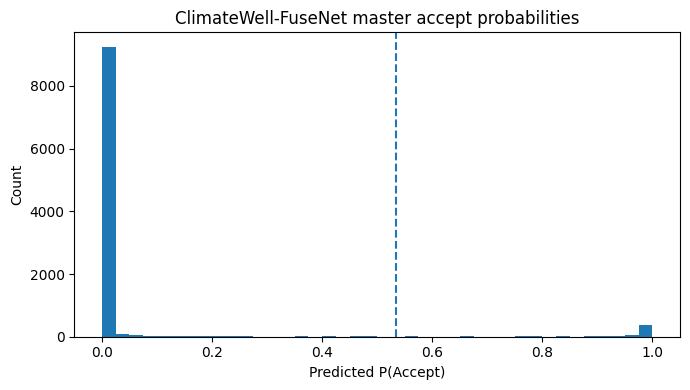

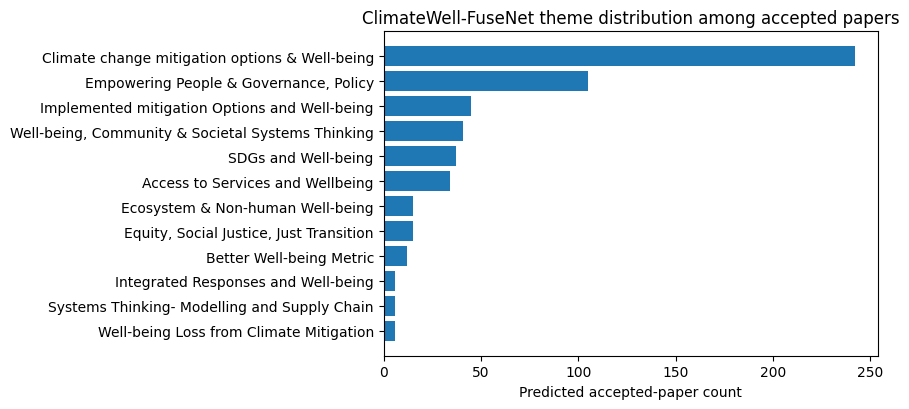

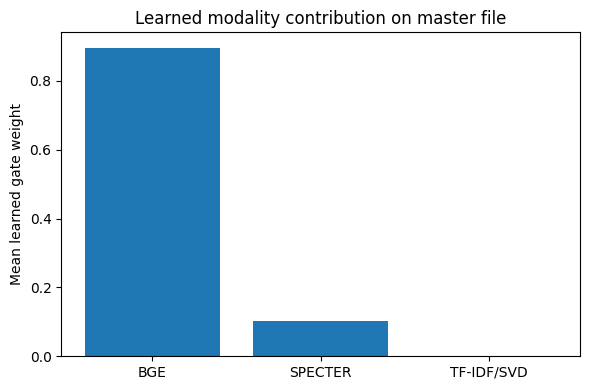

,theme,predicted_count,share_of_accepted
0,Climate change mitigation options & Well-being,242,0.429078
1,"Empowering People & Governance, Policy",105,0.186170
2,Implemented mitigation Options and Well-being,45,0.079787
3,"Well-being, Community & Societal Systems Thinking",41,0.072695
4,SDGs and Well-being,37,0.065603
5,Access to Services and Wellbeing,34,0.060284
6,"Equity, Social Justice, Just Transition",15,0.026596
7,Ecosystem & Non-human Well-being,15,0.026596
8,Better Well-being Metric,12,0.021277
9,Integrated Responses and Well-being,6,0.010638


,modality,mean_gate_master,std_gate_master
0,BGE,0.895858,0.296955
1,SPECTER,0.103035,0.295454
2,TF-IDF/SVD,0.001107,0.011226


In [11]:

# ============================================================
# 10. Theme distribution, gates, plots, and run summary
# ============================================================
theme_distribution = (
    out.loc[out["pred_decision"].eq("Accept"), "pred_theme"]
    .value_counts()
    .rename_axis("theme")
    .reset_index(name="predicted_count")
)
theme_distribution["share_of_accepted"] = theme_distribution["predicted_count"] / max(1, int(out["pred_decision"].eq("Accept").sum()))
theme_distribution.to_csv(OUTPUT_DIR / "climatewell_fusenet_master_theme_distribution.csv", index=False)

# Gate summaries help prove the model is doing learned fusion rather than simple concatenation.
gate_summary = pd.DataFrame({
    "modality": ["BGE", "SPECTER", "TF-IDF/SVD"],
    "mean_gate_master": [out["gate_bge"].mean(), out["gate_specter"].mean(), out["gate_tfidf"].mean()],
    "std_gate_master": [out["gate_bge"].std(), out["gate_specter"].std(), out["gate_tfidf"].std()],
})
gate_summary.to_csv(OUTPUT_DIR / "climatewell_fusenet_gate_summary.csv", index=False)

# Run summary JSON
summary = {
    "method_name": "ClimateWell-FuseNet",
    "description": "Hierarchical gated scientific-semantic fusion architecture with BGE, SPECTER, TF-IDF/SVD, multi-task binary/theme heads, theme prototypes, and uncertainty review score.",
    "n_training_rows": int(len(train_df)),
    "n_master_rows": int(len(master_df)),
    "n_accept_train": int(train_df["accept_label"].sum()),
    "train_accept_rate": float(train_df["accept_label"].mean()),
    "n_themes": int(N_THEMES),
    "final_experiment": FINAL_EXPERIMENT_NAME,
    "final_threshold": FINAL_THRESHOLD,
    "master_pred_accept_count": int(master_pred_accept.sum()),
    "master_pred_accept_rate": float(master_pred_accept.mean()),
    "theme_distribution": theme_distribution.set_index("theme")["predicted_count"].to_dict(),
    "gate_summary": gate_summary.to_dict(orient="records"),
}
with open(OUTPUT_DIR / "climatewell_fusenet_run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Plots
plt.figure(figsize=(7,4))
plt.hist(out["pred_accept_probability"], bins=40)
plt.axvline(FINAL_THRESHOLD, linestyle="--")
plt.xlabel("Predicted P(Accept)")
plt.ylabel("Count")
plt.title("ClimateWell-FuseNet master accept probabilities")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "climatewell_fusenet_accept_probability_histogram.png", dpi=200)
plt.show()

if len(theme_distribution) > 0:
    tmp = theme_distribution.sort_values("predicted_count")
    plt.figure(figsize=(9, max(4, 0.35*len(tmp))))
    plt.barh(tmp["theme"], tmp["predicted_count"])
    plt.xlabel("Predicted accepted-paper count")
    plt.title("ClimateWell-FuseNet theme distribution among accepted papers")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "climatewell_fusenet_theme_distribution.png", dpi=200)
    plt.show()

plt.figure(figsize=(6,4))
plt.bar(gate_summary["modality"], gate_summary["mean_gate_master"])
plt.ylabel("Mean learned gate weight")
plt.title("Learned modality contribution on master file")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "climatewell_fusenet_gate_weights.png", dpi=200)
plt.show()

display(theme_distribution)
display(gate_summary)

In [12]:

# ============================================================
# 11. Auto-generate methodology/result note
# ============================================================
best_nn = ablation_nn_df.iloc[0]
final_nn = ablation_nn_df.loc[ablation_nn_df["experiment"].eq(FINAL_EXPERIMENT_NAME)].iloc[0]

def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

note = []
note.append("# ClimateWell-FuseNet Methodology and Result Note")
note.append("")
note.append("## Proposed architecture")
note.append("ClimateWell-FuseNet is a hierarchical gated fusion architecture that integrates BGE semantic embeddings, SPECTER scientific-document embeddings, and TF-IDF/SVD lexical features. Each modality is projected into a shared neural space, a trainable softmax gate learns modality weights, and the fused representation is used by a binary Accept/Reject head and an accepted-only theme annotation head. A theme-prototype similarity module supports low-resource theme classification, while an uncertainty score prioritises human review.")
note.append("")
note.append("## Final selected experiment")
note.append(f"- Final model: **{FINAL_EXPERIMENT_NAME}**")
note.append(f"- OOF Stage 1 AP: **{fmt(final_nn.get('stage1_AP'))}**")
note.append(f"- OOF binary macro-F1: **{fmt(final_nn.get('stage1_binary_macro_f1'))}**")
note.append(f"- OOF accept F1: **{fmt(final_nn.get('stage1_accept_f1'))}**")
note.append(f"- OOF theme macro-F1: **{fmt(final_nn.get('stage2_theme_macro_f1'))}**")
note.append(f"- OOF theme weighted-F1: **{fmt(final_nn.get('stage2_theme_weighted_f1'))}**")
note.append(f"- Master accept rate: **{fmt(master_pred_accept.mean())}**")
note.append("")
note.append("## Best neural ablation")
note.append(f"- Best neural experiment by selection score: **{best_nn['experiment']}**")
note.append(f"- Theme macro-F1: **{fmt(best_nn.get('stage2_theme_macro_f1'))}**")
note.append(f"- Stage 1 AP: **{fmt(best_nn.get('stage1_AP'))}**")
note.append("")
note.append("## Novelty statement")
note.append("The novelty should be framed as an architectural and task-specific contribution, not as the invention of a new transformer backbone. The core contribution is the trainable hierarchical gated fusion of general semantic, scientific-document, and lexical policy representations, combined with a prototype-based theme module for imbalanced climate-policy evidence annotation.")
note.append("")
note.append("## Reporting caution")
note.append("Only claim that ClimateWell-FuseNet is empirically better if its theme macro-F1 and accept/reject performance improve over the previous hybrid and classical ablation baselines. If the older BGE+TF-IDF model still has stronger theme macro-F1, report ClimateWell-FuseNet as a proposed novel architecture with mixed empirical results and discuss limitations.")

note_path = OUTPUT_DIR / "climatewell_fusenet_methodology_result_note.md"
with open(note_path, "w", encoding="utf-8") as f:
    f.write("\n".join(note))

print("Saved methodology note:", note_path)
print("\n".join(note[:25]))

Saved methodology note: /kaggle/working/climatewell_fusenet_outputs/climatewell_fusenet_methodology_result_note.md
# ClimateWell-FuseNet Methodology and Result Note

## Proposed architecture
ClimateWell-FuseNet is a hierarchical gated fusion architecture that integrates BGE semantic embeddings, SPECTER scientific-document embeddings, and TF-IDF/SVD lexical features. Each modality is projected into a shared neural space, a trainable softmax gate learns modality weights, and the fused representation is used by a binary Accept/Reject head and an accepted-only theme annotation head. A theme-prototype similarity module supports low-resource theme classification, while an uncertainty score prioritises human review.

## Final selected experiment
- Final model: **CLIMATEWELL_FUSENET_BGE_SPECTER_TFIDF**
- OOF Stage 1 AP: **0.3798**
- OOF binary macro-F1: **0.6825**
- OOF accept F1: **0.4502**
- OOF theme macro-F1: **0.1472**
- OOF theme weighted-F1: **0.3103**
- Master accept rate: **0.0554**



In [13]:

# ============================================================
# 12. Zip all outputs for easy download
# ============================================================
import zipfile
zip_path = OUTPUT_DIR.parent / "climatewell_fusenet_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUTPUT_DIR.parent))
print("Zipped outputs:", zip_path)

Zipped outputs: /kaggle/working/climatewell_fusenet_outputs.zip


## How to interpret the notebook

Use this notebook to support the claim of a **proposed novel deep-learning architecture** because it contains trainable architecture-level components, not only fixed feature concatenation.

### Strong claim you can make if results improve

> ClimateWell-FuseNet outperformed the classical BGE/SPECTER/TF-IDF baselines while maintaining a stable master accept rate, showing that trainable gated fusion improves both relevance screening and accepted-only theme annotation.

### More cautious claim if results are mixed

> ClimateWell-FuseNet provides a novel architecture-level extension of the previous hybrid embedding–lexical pipeline. Although its empirical gains are mixed, it demonstrates how general semantic, scientific-document, and lexical policy features can be integrated through learned modality gates, hierarchical task heads, theme prototypes, and uncertainty-aware review prioritisation.